In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from  sklearn.metrics import accuracy_score, precision_score
import matplotlib as plt


In [2]:
Emp_turnover = pd.read_csv("employee_turnover.csv")
Emp_turnover.info()
Emp_turnover.shape 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Job_Satisfaction                         1350 non-null   float64
 1   Performance_Rating                       1350 non-null   float64
 2   Years_At_Company                         1350 non-null   float64
 3   Work_Life_Balance                        1350 non-null   float64
 4   Distance_From_Home                       1350 non-null   float64
 5   Monthly_Income                           1350 non-null   float64
 6   Education_Level                          1350 non-null   float64
 7   Age                                      1350 non-null   float64
 8   Num_Companies_Worked                     1350 non-null   float64
 9   Employee_Role                            1350 non-null   float64
 10  Annual_Bonus                             1350 no

(1350, 16)

In [3]:
Emp_turnover.isnull().sum()
Emp_turnover.isna().sum()

Job_Satisfaction                           0
Performance_Rating                         0
Years_At_Company                           0
Work_Life_Balance                          0
Distance_From_Home                         0
Monthly_Income                             0
Education_Level                            0
Age                                        0
Num_Companies_Worked                       0
Employee_Role                              0
Annual_Bonus                               0
Training_Hours                             0
Department                                 0
Annual_Bonus_Squared                       0
Annual_Bonus_Training_Hours_Interaction    0
Employee_Turnover                          0
dtype: int64

In [4]:
Emp_turnover.sample(10)

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
564,0.050981,0.242201,0.919279,0.436204,0.954682,0.159300,0.490269,0.552592,0.279283,0.896525,0.871426,0.457123,0.150755,0.759383,0.398349,1
1331,0.747742,0.519464,0.539450,0.951501,0.738357,0.566778,0.392735,0.164328,0.115730,0.299666,0.692804,0.191553,0.131462,0.479978,0.132708,1
1060,0.988705,0.430347,0.656127,0.849046,0.439883,0.154978,0.789998,0.941178,0.681608,0.609516,0.880007,0.924532,0.273572,0.774412,0.813594,1
1292,0.872528,0.606816,0.371749,0.369094,0.066707,0.342521,0.245684,0.608551,0.720163,0.292425,0.546147,0.787080,0.641904,0.298277,0.429862,1
317,0.945187,0.887672,0.261361,0.864227,0.350367,0.123268,0.743622,0.808885,0.986781,0.480957,0.251023,0.065392,0.413184,0.063012,0.016415,1
926,0.142472,0.289109,0.679182,0.844545,0.592898,0.522985,0.109609,0.146540,0.958191,0.002625,0.484419,0.756342,0.209963,0.234661,0.366386,1
1284,0.617499,0.931259,0.201226,0.786101,0.106897,0.589108,0.961687,0.998365,0.131600,0.049944,0.472496,0.376194,0.589010,0.223252,0.177750,1
469,0.614978,0.156636,0.914822,0.058502,0.919235,0.113799,0.900870,0.367891,0.789841,0.394238,0.733156,0.852391,0.525439,0.537518,0.624936,1
1240,0.972888,0.094400,0.210237,0.276943,0.766004,0.078973,0.894397,0.218987,0.718028,0.760552,0.893084,0.207539,0.723268,0.797599,0.185350,0
780,0.614512,0.118932,0.588722,0.373266,0.604720,0.736299,0.839010,0.304623,0.483351,0.404795,0.986737,0.566227,0.089418,0.973650,0.558717,1


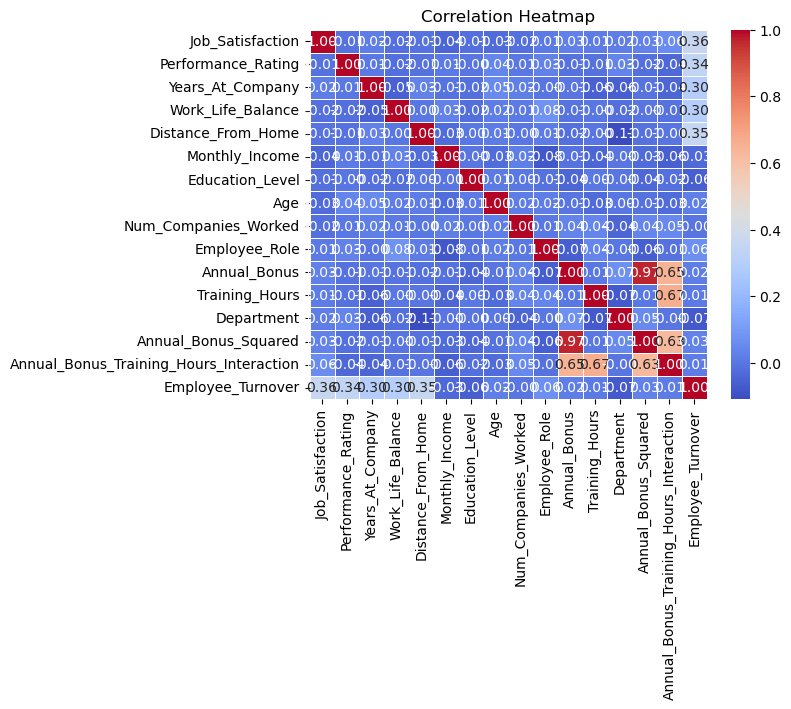

In [6]:
# Calculate the correlation matrix
correlation = Emp_turnover.corr()

# Plot the heatmap
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.pyplot.title("Correlation Heatmap")
plt.pyplot.show()

In [7]:
x_train, x_test, y_train, y_test = train_test_split(Emp_turnover.drop(columns=["Employee_Turnover"]),
                                                    Emp_turnover[["Employee_Turnover"]],
                                                    test_size=0.2, random_state=42)

In [8]:
x_train.shape


(1080, 15)

In [9]:
count_of_zeros = (y_train['Employee_Turnover'] == 0).sum()
print(f"Number of 0s in the dataset: {count_of_zeros}")

Number of 0s in the dataset: 533


In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train.values.ravel()) 
y_pred = model.predict(x_test)

precision_score_train = precision_score(y_train, model.predict(x_train))  
precision_score_test = precision_score(y_test, y_pred)  
accuracyScore = accuracy_score(y_test, y_pred)
print(f"accuracyScore test : {accuracy_score}")
print(f"precision_score train :{precision_score_train}")
print(f"precision_score test : {precision_score_test}")

accuracyScore test : <function accuracy_score at 0x00000236A7ECF9C0>
precision_score train :0.8690036900369004
precision_score test : 0.8717948717948718


In [20]:
from sklearn.linear_model import LogisticRegressionCV

a = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

Lasso_CV = LogisticRegressionCV(max_iter=100,
                   alphas=a,
                   cv=10,
                   random_state=42)

Lasso_CV.fit(x_train,y_train)

print("best alpha: ", Lasso_CV.alpha_)

y_pred = Lasso_CV.predict(x_test)

# Convert continuous predictions to binary predictions
y_pred_binary = [1 if pred >= 0.5 else 0 for pred in y_pred]

acc_score = accuracy_score(y_test, y_pred_binary)
precision_scorE = precision_score(y_test, y_pred_binary)
print("accuracy = ", acc_score)
print("precision_score = ", precision_scorE)


TypeError: LogisticRegressionCV.__init__() got an unexpected keyword argument 'alphas'